## Setup

In [1]:
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np

# Get all files
directory = Path('./rundir')

# Filter for .nc files
nc_files = [f.name for f in directory.glob('*0.nc')]
print(len(nc_files))
ds = xr.open_mfdataset([f'./rundir/{f}' for f in nc_files], combine='by_coords').isel(time=slice(1,None))
print(ds.time.shape)
print(ds.nbytes/(1024**3))  # Convert bytes to GB

33
(32,)
0.18237385153770447


In [2]:
from jcm.geometry import Geometry
from jcm.forcing import ForcingData
from jcm.physics.speedy.test_utils import convert_to_speedy_latitudes
from jcm.date import DateData
import pandas as pd
from importlib import resources

# Load the terrain and forcing data (interpolated to the default model grid)
data_dir = resources.files('jcm.data.bc.t30.clim')
geometry = Geometry.from_file(data_dir / 'terrain.nc', target_resolution=None)
geometry = convert_to_speedy_latitudes(geometry)
forcing = ForcingData.from_file(data_dir / 'forcing.nc', target_resolution=None)
get_datedata = lambda i: DateData.zeros(tyear=pd.Timestamp(ds.isel(time=i).time.values).dayofyear/365)

# Visualizing discrepancies

In [3]:
from jcm.physics_interface import PhysicsState
from jcm.physics.speedy.speedy_physics import SpeedyPhysics
from jcm.physics_interface import verify_state
from jcm.constants import grav
import jax
from jax.tree_util import tree_map

def get_speedy_state(times=None):
    if times is None:
        times = list(range(ds.time.shape[0]))
    ds_times = ds.isel(time=times)
    u, v, t, q, phi, ps = ds_times.u, ds_times.v, ds_times.t, ds_times.q, ds_times.phi, ds_times.ps
    return PhysicsState(
        u_wind = u.values.transpose(0,1,3,2),  # (time, level, lon, lat)
        v_wind = v.values.transpose(0,1,3,2),
        temperature = t.values.transpose(0,1,3,2),
        specific_humidity = q.values.transpose(0,1,3,2) * 1e3,  # convert to g/kg
        geopotential = phi.values.transpose(0,1,3,2) * grav,
        normalized_surface_pressure = ps.values.transpose(0,2,1) / 1e5,  # (time, lon, lat)
    )

physics = SpeedyPhysics()
get_datedata = lambda i: DateData.zeros(tyear=pd.Timestamp(ds.isel(time=i).time.values).dayofyear/365)

def get_tends(times=None):
    if times is None:
        times = list(range(ds.time.shape[0]))
    state = verify_state(get_speedy_state(times))
    dates = [get_datedata(t) for t in times]

    vmapped_compute = jax.vmap(
        lambda s, d: physics.compute_tendencies(state=s, forcing=forcing, geometry=geometry, date=d),
        in_axes=(0, 0)
    )

    # Stack dates into batched DateData
    batched_date = tree_map(lambda *args: jnp.stack(args), *dates)

    return vmapped_compute(state, batched_date)

In [4]:
n = ds.time.shape[0]

In [5]:
# Get all timesteps at once using vmap
timesteps = list(range(0, n, 1))

# Compute tendencies for all times at once
tendencies, data = get_tends(timesteps)

# Average over the time dimension (axis 0)
avg_tendencies = tree_map(lambda x: jnp.mean(x, axis=0), tendencies)
avg_data = tree_map(lambda x: jnp.mean(x, axis=0), data)

In [6]:
print("jcm variables:")
print(list(data.asdict().keys()))
print("humidity: ", list(data.humidity.asdict().keys()))
print("convection: ", list(data.convection.asdict().keys()))
print("condensation: ", list(data.condensation.asdict().keys()))
print("shortwave_rad: ", list(data.shortwave_rad.asdict().keys()))
print("longwave_rad: ", list(data.longwave_rad.asdict().keys()))
print("mod_radcon: ", list(data.mod_radcon.asdict().keys()))
print("surface_flux: ", list(data.surface_flux.asdict().keys()))
print("date: ", list(data.date.asdict().keys()))
print("land_model: ", list(data.land_model.asdict().keys()))

print("\nspeedy variables:")
print(list(ds.data_vars))

# I split the multi-channel variables, so e.g. tau2 channel 0 in the jcm physicsdata corresponds to tau2_1 in the speedy output

jcm variables:
['shortwave_rad', 'longwave_rad', 'convection', 'mod_radcon', 'humidity', 'condensation', 'surface_flux', 'date', 'land_model']
humidity:  ['rh', 'qsat']
convection:  ['se', 'iptop', 'cbmf', 'qdif', 'precnv']
condensation:  ['precls', 'dtlsc', 'dqlsc']
shortwave_rad:  ['qcloud', 'fsol', 'rsds', 'rsns', 'ozone', 'ozupp', 'zenit', 'stratz', 'gse', 'icltop', 'cloudc', 'cloudstr', 'ftop', 'dfabs', 'compute_shortwave']
longwave_rad:  ['dfabs', 'ftop']
mod_radcon:  ['ablco2', 'alb_l', 'alb_s', 'albsfc', 'snowc', 'tau2', 'st4a', 'stratc', 'flux']
surface_flux:  ['ustr', 'vstr', 'shf', 'evap', 'rlus', 'rlds', 'rlns', 'hfluxn', 'tsfc', 'tskin', 'u0', 'v0', 't0']
date:  ['tyear', 'model_year', 'model_step', 'dt_seconds']
land_model:  ['stl_lm']

speedy variables:
['u', 'v', 't', 'q', 'phi', 'ps', 'qcloud', 'fsol', 'rsds', 'rsns', 'ozone', 'ozupp', 'zenit', 'stratz', 'gse', 'icltop', 'cloudc', 'cloudstr', 'ftop_sw', 'dfabs_sw', 'dfabs_lw', 'ftop_lw', 'se', 'iptop', 'cbmf', 'qdif', 

In [7]:
print(jnp.mean(data.convection.iptop), jnp.mean(ds.iptop.values))

6.2538385 6.249166


jcm mean, min, max:  6.2538385 3.0 9.0
speedy mean, min, max:  6.249166 3.0 9.0


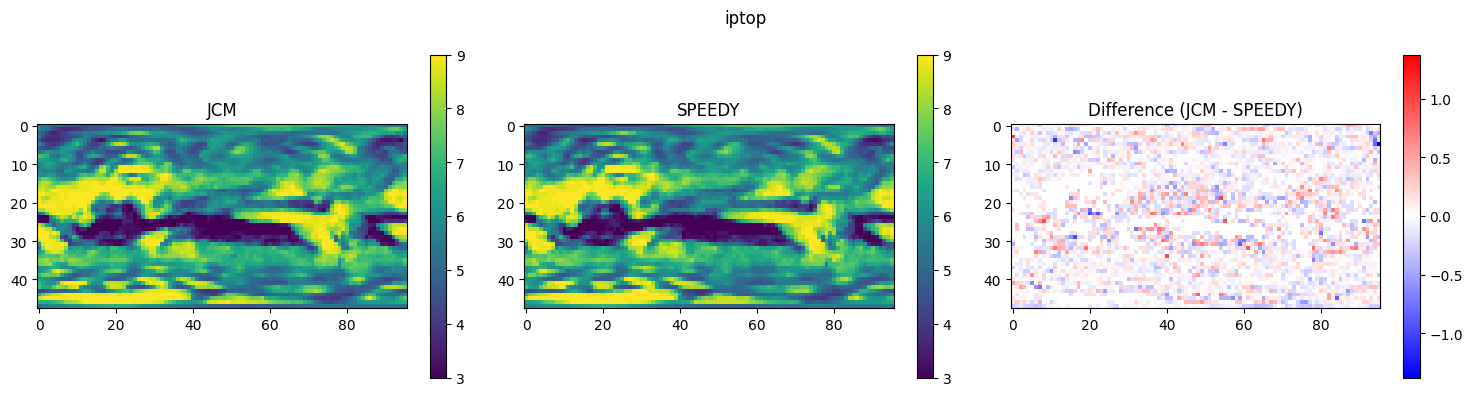

In [8]:
jcm_data = jnp.mean(data.convection.iptop, axis=0).T[::-1]
speedy_data = jnp.mean(ds.iptop.values, axis=0)[::-1]

# need to look at flux
# jcm_data = jnp.mean(data.mod_radcon.flux[...,0], axis=0).T[::-1]
# speedy_data = jnp.mean(ds.flux_1.values, axis=0)[::-1]

# jcm_data = jnp.mean(data.surface_flux.rlds, axis=0).T[::-1]
# speedy_data = jnp.mean(ds.rlds.values, axis=0)[::-1]

# jcm_data = jnp.mean(data.surface_flux.rlus[...,2], axis=0).T[::-1]
# speedy_data = jnp.mean(ds.rlus_3.values, axis=0)[::-1]

# jcm_data = jnp.mean(data.surface_flux.rlns, axis=0).T[::-1]
# speedy_data = jnp.mean(ds.rlns.values, axis=0)[::-1]

# jcm_data = jnp.mean(data.longwave_rad.ftop, axis=0).T[::-1]
# speedy_data = jnp.mean(ds.ftop_lw.values, axis=0)[::-1]

# jcm_data = jnp.mean(data.mod_radcon.flux[...,3], axis=0).T[::-1]
# speedy_data = jnp.mean(ds.flux_4.values, axis=0)[::-1]

# jcm_data = jnp.mean(data.longwave_rad.dfabs, axis=(0,2))
# speedy_data = jnp.mean(ds.dfabs_lw.values, axis=(0,3))
# jcm_data = jnp.mean(data.longwave_rad.dfabs[1], axis=0).T[::-1]
# speedy_data = jnp.mean(ds.dfabs_lw[1].values, axis=0)[::-1]
print("jcm mean, min, max: ", jcm_data.mean(), jcm_data.min(), jcm_data.max())
print("speedy mean, min, max: ", speedy_data.mean(), speedy_data.min(), speedy_data.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

vmax = max(jnp.max(jnp.abs(jcm_data)), jnp.max(jnp.abs(speedy_data)))
vmin = -vmax

im0 = axes[0].imshow(jcm_data)#, vmin=vmin, vmax=vmax, cmap='bwr')
axes[0].set_title('JCM')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(speedy_data)#, vmin=vmin, vmax=vmax, cmap='bwr')
axes[1].set_title('SPEEDY')
plt.colorbar(im1, ax=axes[1])

diff = jcm_data - speedy_data
im2 = axes[2].imshow(diff, cmap='bwr', vmin=-jnp.max(jnp.abs(diff)), vmax=jnp.max(jnp.abs(diff)))
axes[2].set_title('Difference (JCM - SPEEDY)')
plt.colorbar(im2, ax=axes[2])

plt.suptitle('iptop')
plt.tight_layout()
plt.show()

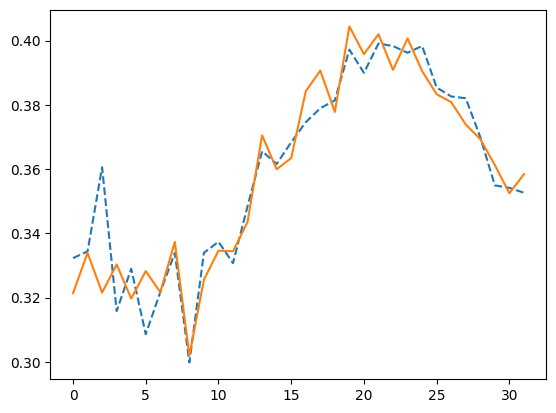

In [9]:
# If you see any discrepancy in the time average, look at the specific location

plt.plot(ds.gse[:,24,50].values, ls='--')
plt.plot(data.shortwave_rad.gse[:,50,24])

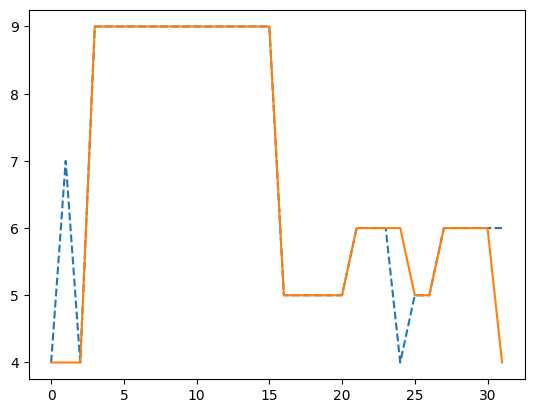

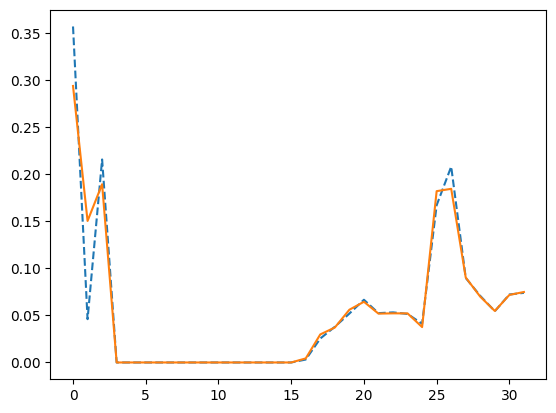

In [10]:
# More examples of testing specific locations

plt.plot(ds.icltop.values[:,-20,-4], ls='--')
plt.plot(data.shortwave_rad.icltop[:,-4,-20])
plt.show()

plt.plot(ds.cloudc.values[:,-20,-4], ls='--')
plt.plot(data.shortwave_rad.cloudc[:,-4,-20])

In [11]:
print(jnp.mean(data.longwave_rad.ftop))
print(jnp.mean(ds.ftop_lw.values))

212.52794
212.55347


# remaining physicsdata discrepancies
* double check for evap biases (for surface fluxes, remember that only the combined land/sea variables matter, after fmask is applied)
* double check rlus
* double check for overall surface temperature bias (in this notebook, that would mean looking at tskin, t0, tsfc rather than the ttend or the jcm equilibrium state)
* I remember seeing a longwave dfabs discrepancy in the stratosphere, worth double checking